# CONSOLIDATE and HYPOTHESIS

Consolidate crime and income using county and year

**Hypothesis**: In Minnesota, higher income levels are related to crime rates.

Null hypothesis (H₀):
There is no association between income levels and crime rates in Minnesota.

Alternative hypothesis (H₁):
There is an association between income levels and crime rates in Minnesota.

**Detailed Description**
This hypothesis proposes a negative relationship between income and crime: as household or community income increases, crime rates are expected to decrease. The rationale is that higher income levels often bring greater access to resources, stable employment, education, and social support—factors that can reduce financial stress and lower the likelihood of criminal activity.
In the context of Minnesota, this relationship can be evaluated by comparing county-level indicators such as median household income and per capita income with reported crime rates, including property crime, violent crime, and total crime. The expectation is that counties with stronger economic conditions will generally report fewer crimes than those with lower income levels.
Additionally, population density will be included as a predictor variable, based on the assumption that more densely populated counties tend to experience higher crime rates due to increased opportunities for criminal encounters and greater social interaction.


In [1082]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)

Data sources:
MN income data = mn_income_clean.csv
MN crime data = mn_crime_clean.csv
Historical crime index = MNHistoricalCrimeIndex 2025.xlsx

In [1084]:
# Load data
mn_income = pd.read_csv("mn_income_clean_2025pred.csv", delimiter=',')
mn_crime = pd.read_csv("mn_crime_clean.csv", delimiter=',')
mn_crime_trend = pd.read_excel("MNHistoricalCrimeIndex 2025.xlsx")

mn_income.columns = mn_income.columns.str.lower()
mn_crime.columns = mn_crime.columns.str.lower()
mn_crime_trend.columns = mn_crime_trend.columns.str.lower()
mn_crime_trend.head(1)

,index year,year population,crime index total,murder,rape,robbery,aggravated assault,burglary,larceny,motor vehicle theft,arson,crime rate,unnamed: 12
0,1936,2563953,16753,38,101,788,274,4778,7203,3571,0,654.6,653.405113


In [1085]:
# merge all data into one data frame
mn_crime_vs_income = mn_crime.merge(
    mn_income,
    on=["county", "year"]
)
# Normalize by adding per 1000 county population size
mn_crime_vs_income['crime_rate_per_1000'] = (
    mn_crime_vs_income['total_crime'] / mn_crime_vs_income['county population'] * 1000
)

mn_crime_vs_income['crime_rate_per_1000_wolarceny'] = (
    mn_crime_vs_income['total_crime']- mn_crime_vs_income['all other larceny']/ mn_crime_vs_income['county population'] * 1000
)

mn_crime_vs_income['mean_income_rate_per_1000'] = (
    mn_crime_vs_income['mean income (dollars)'] / mn_crime_vs_income['county population'] * 1000
)

mn_crime_vs_income.head(1)
mn_crime_vs_income.to_csv("mn_income_merged.csv", index=False)

## **_MN Crime Index Total and Population Total by Year (Post-2001)_**

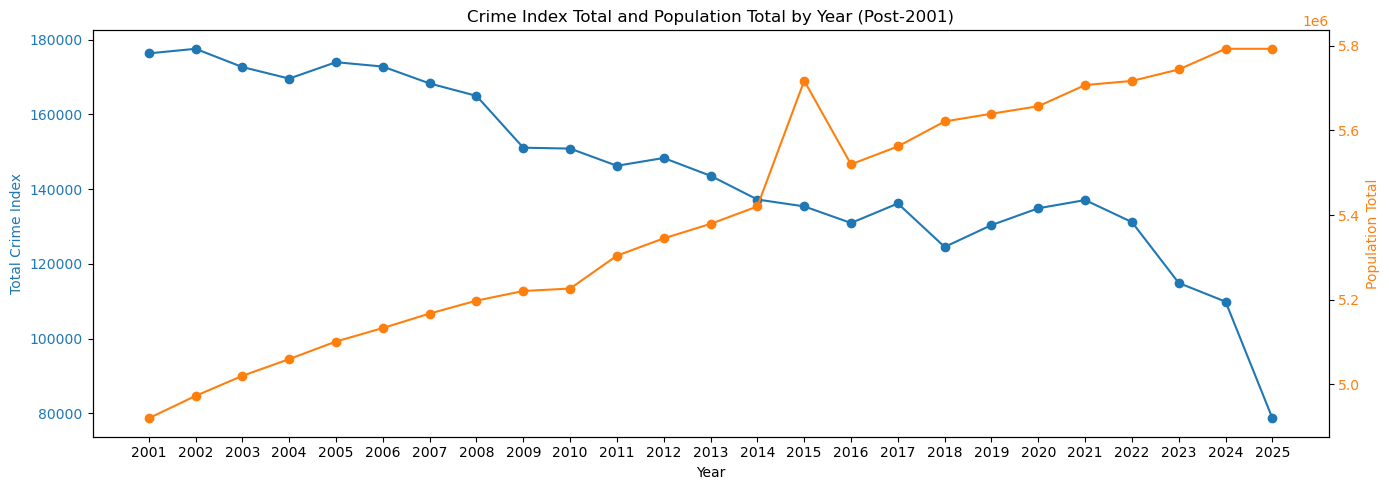

In [1087]:
mn_crime_trend_total = (
    mn_crime_trend[mn_crime_trend['index year'] > 2000]
    .groupby('index year')[['crime index total', 'year population']]
    .sum()
)

mn_crime_trend_total['crime_rate_per_1000'] = mn_crime_trend_total['crime index total'] / (mn_crime_trend_total['year population'] / 1000)
# Create primary axis
fig, ax1 = plt.subplots(figsize=(14,5))

# Plot crime index on left y-axis
ax1.plot(
    mn_crime_trend_total.index,
    mn_crime_trend_total['crime index total'],
    marker='o',
    color='tab:blue',
    label='Crime Index Total'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crime Index', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create secondary axis for population
ax2 = ax1.twinx()
ax2.plot(
    mn_crime_trend_total.index,
    mn_crime_trend_total['year population'],
    marker='o',
    color='tab:orange',
    label='Population Total'
)
ax2.set_ylabel('Population Total', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Crime Index Total and Population Total by Year (Post-2001)')
plt.xticks(mn_crime_trend_total.index)
plt.tight_layout()
plt.show()

**Observation:**
- _Despite a growing population in Minnesota post-2001, the total crime index has steadily declined, indicating a positive trend in public safety over time._
- _Over the 24-year period, population steadily increases, reflecting growth or migration._
- _Total crime decreases overall, especially sharply in the last few years, despite population growth._

## **_MN Crime Type Distribution per Year_**

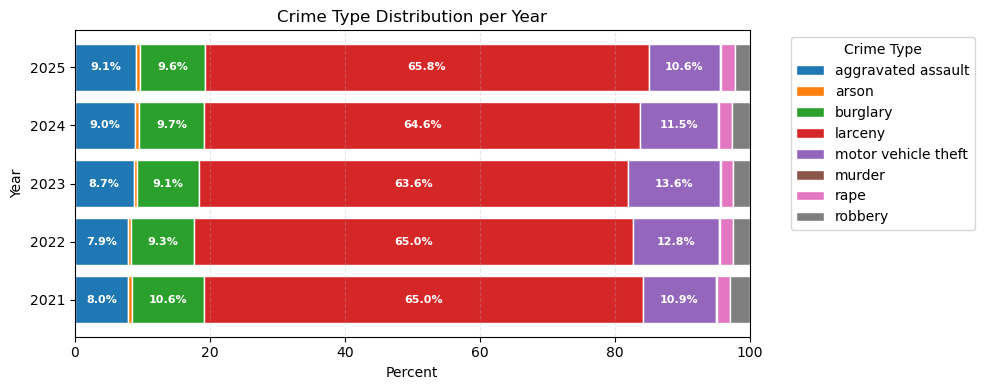

In [1090]:
mn_crime_trend_total = (
    mn_crime_trend[mn_crime_trend['index year'] > 2000]
    .groupby('index year')[['crime index total', 'year population']]
    .sum()
)

mn_crime_after_2021 = mn_crime_trend[mn_crime_trend["index year"] > 2020]

crime_cols = [
    "murder", "rape", "robbery", "aggravated assault",
    "burglary", "larceny", "motor vehicle theft", "arson"
]

df_long = mn_crime_after_2021.melt(
    id_vars=["index year"],
    value_vars=crime_cols,
    var_name="crime_type",
    value_name="sum"
)

# Pivot: rows = years, columns = crime types
pivot = df_long.pivot(index="index year", columns="crime_type", values="sum")

# Convert to percent per year (row)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 4))

# Track left position for stacking
left = [0] * len(pivot_pct)

for crime in pivot_pct.columns:
    values = pivot_pct[crime]
    
    # Draw each stacked segment
    bars = plt.barh(
        pivot_pct.index,
        values,
        left=left,
        label=crime,
        edgecolor="white"
    )
    
    # Add percent labels inside each bar section
    for bar, pct in zip(bars, values):
        if pct > 3:   # show labels only if large enough to be readable
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                fontweight="bold"
            )
    
    # Update left positions for stacking
    left = left + values

plt.xlabel("Percent")
plt.ylabel("Year")
plt.title("Crime Type Distribution per Year")

plt.xlim(0, 100)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**

_This chart displays how different categories of crime contribute to the total crime share each year from 2021 to 2025.
Larceny prevention, since it is the core driver of crime totals, every year consistently making up 64–66% of all crime — by far the largest crime category. Motor vehicle theft is the second-largest category, hovering around 10–13%. Aggravated assault remains stable around 8–9%. Burglary gradually declines from ~0.6% in 2021 to 9.1–9.6% in later years._


## **_Income vs Crime Rate per 1,000 (Colored by Income)_**

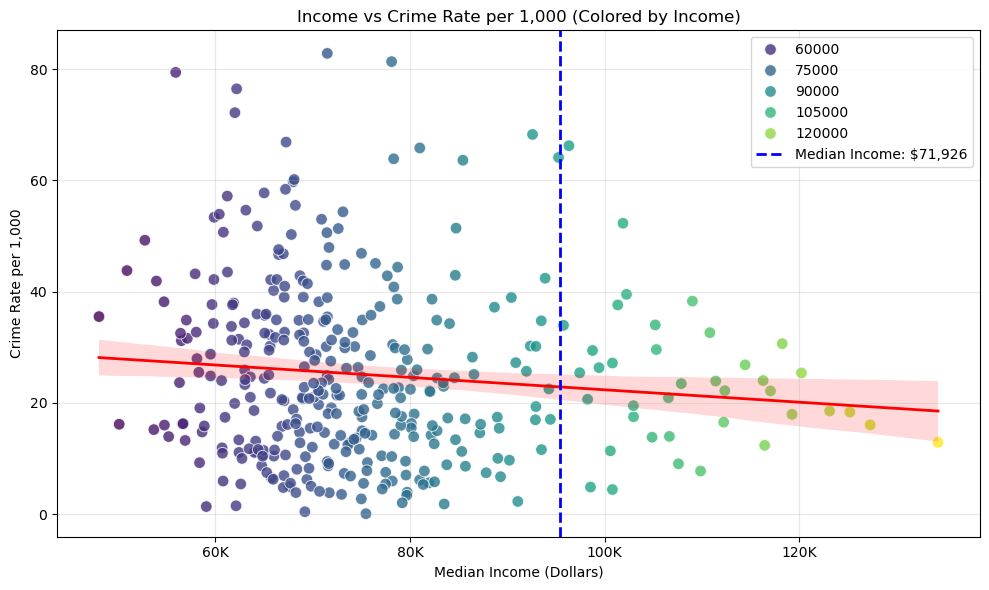

In [1093]:
# Calculate average income

avg_income = mn_crime_vs_income['mean income (dollars)'].mean()
median_income = mn_crime_vs_income['median income (dollars)'].median()
plt.figure(figsize=(10,6))

# Scatter with color mapped to income
sns.scatterplot(
    data=mn_crime_vs_income,
    x='median income (dollars)',
    y='crime_rate_per_1000',
    hue='median income (dollars)',
    palette='viridis',
    s=70,
    alpha=0.8
)

# Regression line
sns.regplot(
    data=mn_crime_vs_income,
    x='median income (dollars)',
    y='crime_rate_per_1000',
    scatter=False,
    line_kws={'color':'red', 'linewidth':2}
)

# Add vertical line for average income
plt.axvline(avg_income, color='blue', linestyle='--', linewidth=2, label=f'Median Income: ${median_income:,.0f}')
# {int(bottom5_data['median income (dollars)'].mean()/1000)}K)
plt.title('Income vs Crime Rate per 1,000 (Colored by Income)')
plt.xlabel('Median Income (Dollars)')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.ylabel('Crime Rate per 1,000')
plt.legend()  
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**

This scatterplot compares mean income and crime rate, with every point representing a county.
Crime values vary widely across the income spectrum.
Income is not a strong predictor of crime rate by itself.
While poorer counties tend to have somewhat higher crime, the wide spread suggests other factors (population density, urbanization, policing, housing instability, substance abuse rates, etc.) play larger roles.

- The regression line shows a very slight negative slope:
- Higher income, slightly lower crime, but the effect is weak.
- Points are widely scattered, meaning income alone does not strongly predict crime rates.
- A dashed vertical line marks the average Minnesota mean income is 95K and median is 75K.

In [1095]:
# Compute yearly averages
yearly_avg = mn_crime_vs_income.groupby("year").agg({
    "county population": "sum",    
    "mean income (dollars)": "mean",
    "total_crime": "mean",
    "crime_rate_per_1000": "mean",
    "mean_income_rate_per_1000":"mean"
}).reset_index()

print(yearly_avg)


   year  county population  mean income (dollars)   total_crime  \
0  2021          5703654.0           84163.197674   3213.953488   
1  2022          5713291.0           91602.151163   3030.872093   
2  2023          5740384.0           95493.220930   2698.267442   
3  2024          4263544.0          119235.250000  11457.250000   
4  2025          5789338.0          106200.679070   1945.151163   

   crime_rate_per_1000  mean_income_rate_per_1000  
0            31.923046                5091.407934  
1            27.752651                5502.904620  
2            23.620896                5639.751514  
3            32.469325                 834.516833  
4            15.560223                6458.167808  


## **_High-risk Minnesota Counties (Low income + high crime)_**

Avg Income Rate per 1000: 5673.85
Avg Crime Total: 2694.78
Avg Crime Rate per 1000: 24.55
Median Income: 75054.20

Top 5 High-Risk Counties (Low Income + High Crime):

    county  median income (dollars)  crime_rate_per_1000
  beltrami                66016.725            66.790780
mille lacs                70836.100            53.152695
blue earth                71420.180            49.480318
 st. louis                68063.280            43.574204
   stearns                74895.060            43.336302


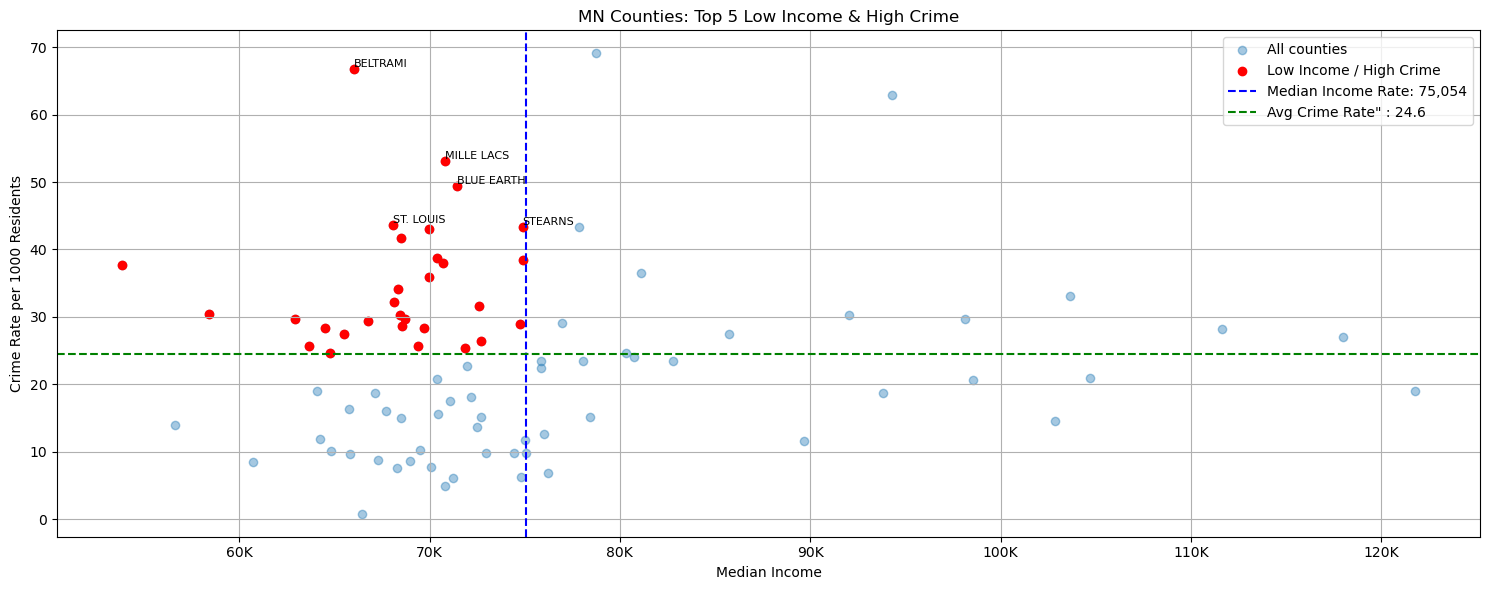

In [1097]:

# Compute county-level means

mn_crime_vs_income_means = (
    mn_crime_vs_income
    .groupby("county")
    .agg({
        "mean income (dollars)": "mean",
        "median income (dollars)": "mean",
        "total_crime": "mean",
        "crime_rate_per_1000": "mean",
        "mean_income_rate_per_1000": "mean",
        "county population":"mean"     
    })
    .reset_index()
)

# Add ranks (highest value = rank 1)
mn_crime_vs_income_means["population_rank"] = (mn_crime_vs_income_means["county population"].rank(ascending=False, method="min"))
mn_crime_vs_income_means["median_income_rank"] = (mn_crime_vs_income_means["median income (dollars)"].rank(ascending=False, method="min"))
mn_crime_vs_income_means["crime_rate_rank"] = (mn_crime_vs_income_means["crime_rate_per_1000"].rank(ascending=False, method="min"))

# Compute statewide averages
avg_income          = mn_crime_vs_income_means["mean income (dollars)"].mean()
avg_median_income   = mn_crime_vs_income_means["median income (dollars)"].mean()
avg_crime           = mn_crime_vs_income_means["total_crime"].mean()
avg_crime_rate      = mn_crime_vs_income_means["crime_rate_per_1000"].mean()
avg_income_rate     = mn_crime_vs_income_means["mean_income_rate_per_1000"].mean()

print(f"Avg Income Rate per 1000: {avg_income_rate:.2f}")
print(f"Avg Crime Total: {avg_crime:.2f}")
print(f"Avg Crime Rate per 1000: {avg_crime_rate:.2f}")
print(f"Median Income: {avg_median_income:.2f}")

# Identify high-risk counties - Low income + high crime

high_risk = mn_crime_vs_income_means[
    (mn_crime_vs_income_means["median income (dollars)"] < avg_median_income) &
    (mn_crime_vs_income_means["crime_rate_per_1000"] > avg_crime_rate)
]

# print("\nHigh-Risk Counties:")
# print(high_risk[["county", "median income (dollars)", "crime_rate_per_1000"]])

# Top 5 highest crime counties among the high-risk ones
top5 = high_risk.nlargest(5, "crime_rate_per_1000")
print("\nTop 5 High-Risk Counties (Low Income + High Crime):\n")
print(top5[["county", "median income (dollars)", "crime_rate_per_1000"]].to_string(index=False))


# Scatter plot

plt.figure(figsize=(15, 6))

# All counties
plt.scatter(
    mn_crime_vs_income_means["median income (dollars)"],
    mn_crime_vs_income_means["crime_rate_per_1000"],
    alpha=0.4,
    label="All counties"
)

# High-risk counties
plt.scatter(
    high_risk["median income (dollars)"],
    high_risk["crime_rate_per_1000"],
    color="red",
    label="Low Income / High Crime"
)

# State average reference lines
plt.axvline(avg_median_income, color="blue", linestyle="--", label= f'Median Income Rate: {avg_median_income:,.0f}')
plt.axhline(avg_crime_rate, color="green", linestyle="--", label=f'Avg Crime Rate" : {avg_crime_rate:,.1f}')

plt.title("MN Counties: Top 5 Low Income & High Crime")
plt.xlabel("Median Income")

# Format x-axis labels in thousands with 'K'
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.ylabel("Crime Rate per 1000 Residents")
plt.legend()
plt.grid(True)

# Add text labels for top 5 counties
for _, row in top5.iterrows():
    plt.text(
        row["median income (dollars)"],
        row["crime_rate_per_1000"],
        row["county"].upper(),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.tight_layout()
plt.show()

This plot highlights counties that fall into the high-risk quadrant:
- Income below state average
- Crime rate above state average

The top 5 counties in this category show both socioeconomic stress (low income) and public safety issues (high crime).

- _Beltrami County has an median income of around 66K but experiences a very high crime rate (66), making it the most pronounced outlier and a clear high-risk area._
- _Mille Lacs County has an income of roughly 79K and a high crime rate, marking it as a significant crime hotspot compared to other counties._
- _Blue Earth County earns about 71K on average and shows a moderately high crime rate, placing it above the statewide crime average._
- _St Louis and Stearns County has one of the lower incomes at approximately $68 and 74K respectively and an elevated crime rate, indicating that it is consistently among the at-risk counties in the state._

## **_Filter top 5 by each category_**
Top 5 counties rank by Population size, Median Income and Crime Rate

In [1100]:
# Filter top 5 by each category
top5_population = mn_crime_vs_income_means[mn_crime_vs_income_means['population_rank'] <= 5]
top5_income = mn_crime_vs_income_means[mn_crime_vs_income_means['median_income_rank'] <= 5]
top5_crime = mn_crime_vs_income_means[mn_crime_vs_income_means['crime_rate_rank'] <= 5]

# Display the tables in a clear format
print("Top 5 Counties by Population:")
top5_population = top5_population.sort_values('population_rank')
display(top5_population[['county', 'county population', 'median income (dollars)', 'crime_rate_per_1000', 'population_rank']])


print("\nTop 5 Counties by Median Income:")
top5_income = top5_income.sort_values('median_income_rank')
display(top5_income[['county', 'median income (dollars)', 'county population', 'crime_rate_per_1000', 'median_income_rank']])

print("\nTop 5 Counties by Crime Rate:")
top5_crime = top5_crime.sort_values('crime_rate_rank')
display(top5_crime[['county', 'crime_rate_per_1000', 'median income (dollars)', 'county population', 'crime_rate_rank']])

Top 5 Counties by Population:


,county,county population,median income (dollars),crime_rate_per_1000,population_rank
26,hennepin,1269204.0,94308.46,62.907664,1.0
60,ramsey,531907.2,78731.84,69.060804,2.0
18,dakota,445466.6,103631.92,33.168626,3.0
1,anoka,372684.4,98121.28,29.739171,4.0
80,washington,278786.8,111649.62,28.176473,5.0



Top 5 Counties by Median Income:


,county,median income (dollars),county population,crime_rate_per_1000,median_income_rank
9,carver,121788.76,111367.6,19.000128,1.0
67,scott,117966.16,160015.2,26.970146,2.0
80,washington,111649.62,278786.8,28.176473,3.0
68,sherburne,104696.94,95098.8,20.997949,4.0
18,dakota,103631.92,445466.6,33.168626,5.0



Top 5 Counties by Crime Rate:


,county,crime_rate_per_1000,median income (dollars),county population,crime_rate_rank
60,ramsey,69.060804,78731.840,531907.20,1.0
3,beltrami,66.790780,66016.725,47227.75,2.0
26,hennepin,62.907664,94308.460,1269204.00,3.0
46,mille lacs,53.152695,70836.100,27493.75,4.0
6,blue earth,49.480318,71420.180,70656.80,5.0


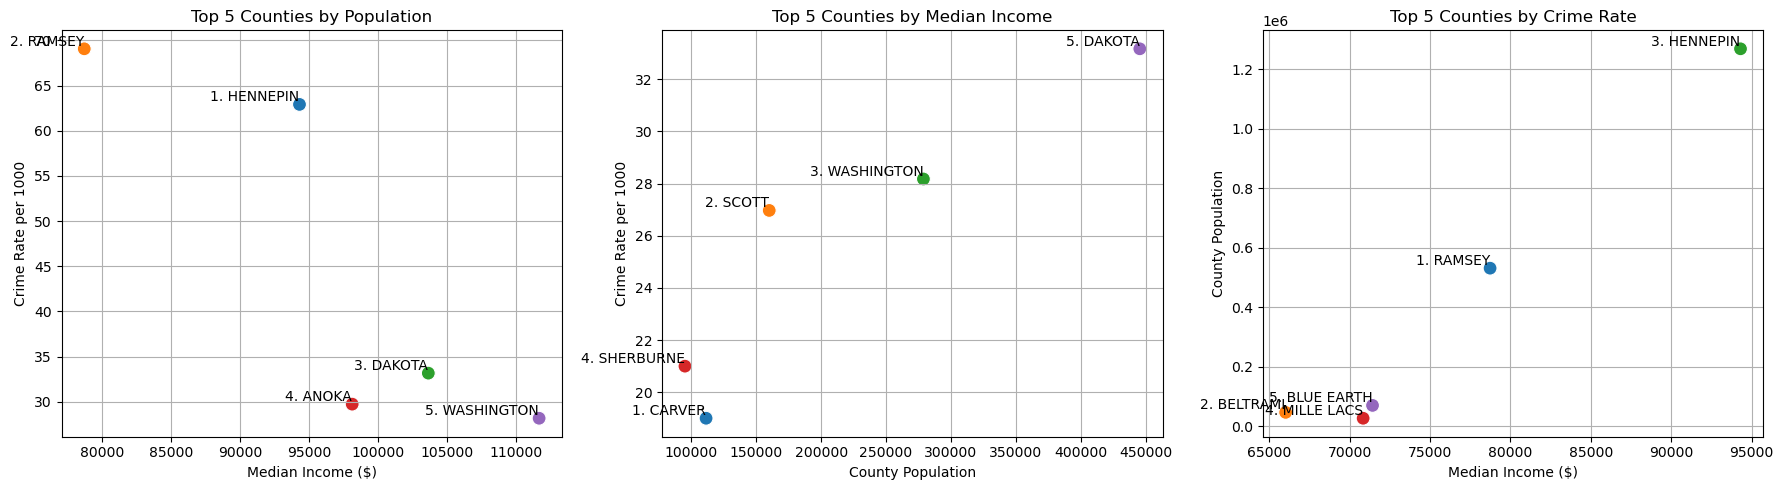

In [1101]:
# Create a figure with 3 subplots
plt.figure(figsize=(18,5))

# 1. Top 5 by population
plt.subplot(1,3,1)
sns.scatterplot(
    data=top5_population, 
    x='median income (dollars)', 
    y='crime_rate_per_1000', 
    hue='county', s=100
)
for i, row in top5_population.iterrows():
    label = f"{row['population_rank']:,.0f}. {row['county'].upper()}"
    plt.text(row['median income (dollars)'], row['crime_rate_per_1000'], label,fontsize=10, color='black', ha='right', va='bottom')  
plt.title('Top 5 Counties by Population')
plt.xlabel('Median Income ($)')
plt.ylabel('Crime Rate per 1000')
plt.legend().remove()
plt.grid(True)

# 2. Top 5 by median income
plt.subplot(1,3,2)
sns.scatterplot(
    data=top5_income, 
    x='county population', 
    y='crime_rate_per_1000', 
    hue='county', s=100
)
for i, row in top5_income.iterrows():
    label = f"{row['median_income_rank']:,.0f}. {row['county'].upper()}"
    plt.text(row['county population'], row['crime_rate_per_1000'], label,fontsize=10, color='black', ha='right', va='bottom')  
plt.title('Top 5 Counties by Median Income')
plt.xlabel('County Population')
plt.ylabel('Crime Rate per 1000')
plt.legend().remove()
plt.grid(True)

# 3. Top 5 by crime rate
plt.subplot(1,3,3)
sns.scatterplot(
    data=top5_crime, 
    x='median income (dollars)', 
    y='county population', 
    hue='county', s=100
)
for i, row in top5_crime.iterrows():
    label = f"{row['crime_rate_rank']:,.0f}. {row['county'].upper()}"
    plt.text(row['median income (dollars)'], row['county population'], label,fontsize=10, color='black', ha='right', va='bottom')  
plt.title('Top 5 Counties by Crime Rate')
plt.xlabel('Median Income ($)')
plt.ylabel('County Population')
plt.legend().remove()
plt.grid(True)

plt.tight_layout()
plt.show()


## Permutation Test

**_1) Test median income vs crime rate across all counties_**

Observed correlation: -0.105
Permutation 95% CI: [-0.101, 0.103]
Permutation p-value (two-sided): 0.0456
Reject H0 (P-value is < 5% and H0 is within CI range)


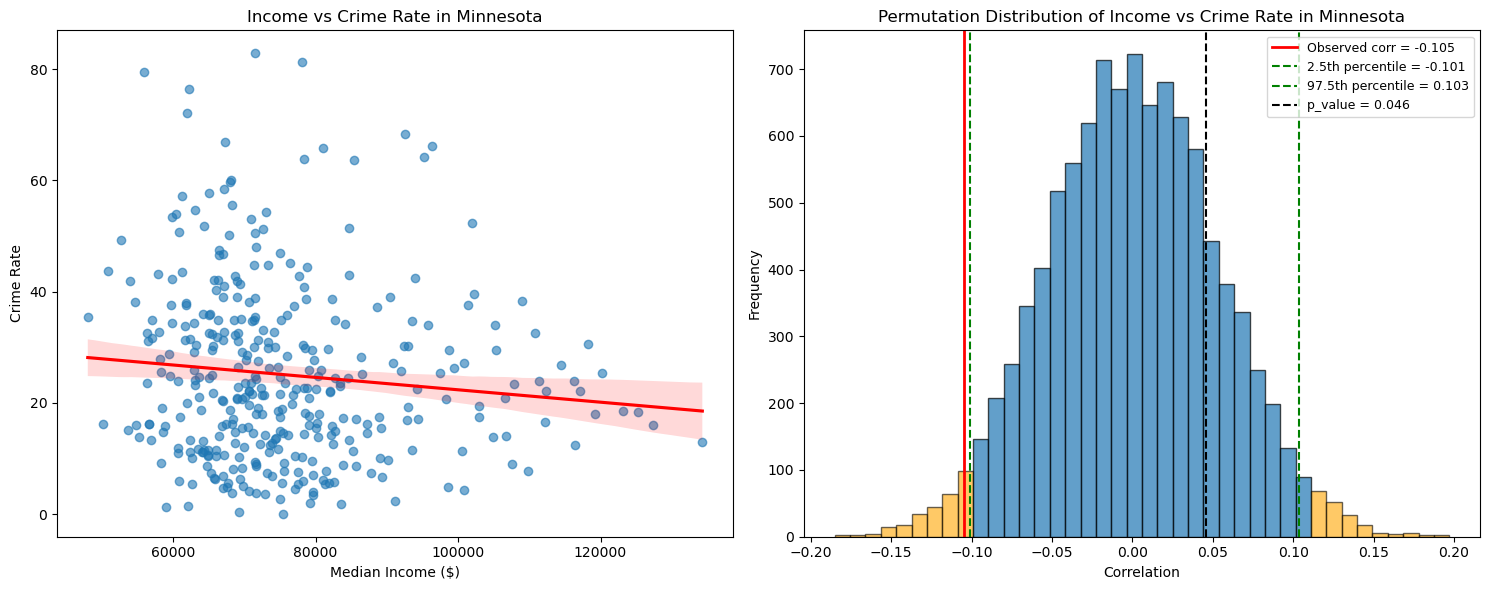

In [1103]:
# Drop missing values
mn_crime_vs_income = mn_crime_vs_income.dropna(subset=['median income (dollars)', 'crime_rate_per_1000'])

# Extract variables
income = mn_crime_vs_income['median income (dollars)'].values
crime  = mn_crime_vs_income['crime_rate_per_1000'].values

# Observed difference
obs_corr = np.corrcoef(income, crime)[0, 1]

#Permutation Test
n_perm = 10_000
perm_corrs = []

np.random.seed(42)
for _ in range(n_perm):
    perm_crime = np.random.permutation(crime)
    perm_corrs.append(np.corrcoef(income, perm_crime)[0, 1])

perm_corrs = np.array(perm_corrs)

# Two-sided p-value
p_value = np.mean(np.abs(perm_corrs) >= np.abs(obs_corr))

# Approximate 95% CI from permutation distribution
ci_low, ci_high = np.percentile(perm_corrs, [2.5, 97.5])

print(f"Observed correlation: {obs_corr:.3f}")
print(f"Permutation 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Permutation p-value (two-sided): {p_value:.4f}")

#Interpretation
threshold = 0.05
null_value = 0 
H0 ="Null hypothesis (H₀): Income and crime rate are not associated (correlation = 0)."
H1 ="Alternative hypothesis (H₁): Income and crime rate are associated (correlation ≠ 0)."

#NOTE:
# If the null value (0 in this case) is inside the CI, it means the data are compatible with 𝐻0 , so you fail to reject 𝐻0
# If the null value is outside the CI, it means the data are incompatible with 𝐻0, so you reject H0 at the corresponding significance level (α=0.05 for a 95% CI)
hypo_interpret = 'Reject H0 (P-value is < 5% and H0 is within CI range)' \
    if (p_value < threshold) \
    else 'Fail to reject H0 (P-value is >5% and outside CI range)\n' + H0
print(hypo_interpret)

# plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Scatter + regression line
sns.regplot(
    x=income, 
    y=crime, 
    ax=axes[0], 
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
axes[0].set_title("Income vs Crime Rate in Minnesota")
axes[0].set_xlabel("Median Income ($)")
axes[0].set_ylabel("Crime Rate")

# Right: Permutation distribution with shaded p-value region
counts, bins, patches = axes[1].hist(perm_corrs, bins=40, edgecolor='black', alpha=0.7)

# Shade extreme areas corresponding to two-sided p-value
for patch, bin_left in zip(patches, bins[:-1]):
    if bin_left <= -abs(obs_corr) or bin_left >= abs(obs_corr):
        patch.set_facecolor('orange')
        patch.set_alpha(0.6)

# Observed correlation and CI lines
axes[1].axvline(obs_corr, color='red', linewidth=2, label=f"Observed corr = {obs_corr:.3f}")
axes[1].axvline(ci_low, color='green', linestyle='--', label=f"2.5th percentile = {ci_low:.3f}")
axes[1].axvline(ci_high, color='green', linestyle='--', label=f"97.5th percentile = {ci_high:.3f}")
axes[1].axvline(p_value, color='black', linestyle='--', label=f"p_value = {p_value:.3f}")
axes[1].set_title("Permutation Distribution of Income vs Crime Rate in Minnesota")
axes[1].set_xlabel("Correlation")
axes[1].set_ylabel("Frequency")

axes[1].legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:**
On the left figure the fitted red line slopes slightly downward, indicating a weak negative relationship.
- Counties with higher income tend to have slightly lower crime rates.
- The points are widely scattered, suggesting high variability and no strong linear pattern.

The permutation distribution (right) shows the distribution of correlations expected under the null hypothesis of no association.
o	The observed correlation is −0.105: indicates a very weak negative association between income and crime rate. i.e. a very weak negative association between income and crime rate: as income increases slightly, crime rate tends to decrease.
o	The 95% permutation confidence interval ranges from −0.101 to 0.103, which includes zero.

- The p-value 0.0456 is very close to the 5% significance threshold. It's borderline significant, suggesting marginal evidence against the null hypothesis of no correlation.

Overall, the data provide only weak evidence of a relationship between median income and crime rate across Minnesota counties. To explore this further, I conducted a permutation test comparing two specific counties—one with high income and one with high crime—to assess the difference in their crime rates.


**_2) Permutation test for selected counties_**
   - Carver - high income county
   - Ramsey - high crime country

Observed difference: 50.06
Permutation p-value: 0.0038
95% Permutation CI: (-34.12, 34.12)
Reject H₀: Null hypothesis (H₀): Income and crime rate are not associated (correlation = 0).


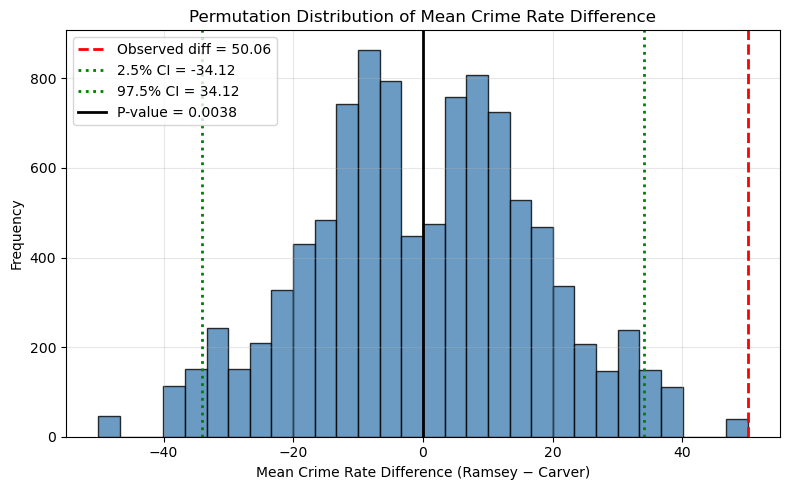

In [1106]:
#CARVER high income county vs Ramsey high Crime county
# Extract raw data
carver = mn_crime_vs_income.query("county == 'carver'")['crime_rate_per_1000'].values
ramsey = mn_crime_vs_income.query("county == 'ramsey'")['crime_rate_per_1000'].values

# Observed difference in means
observed_diff = ramsey.mean() - carver.mean()

# Combine data
combined = np.concatenate([ramsey, carver])
n_r = len(ramsey)

# Permutation test
N_perm = 10_000
perm_diffs = np.empty(N_perm)

for i in range(N_perm):
    np.random.shuffle(combined)
    perm_r = combined[:n_r]
    perm_c = combined[n_r:]
    perm_diffs[i] = perm_r.mean() - perm_c.mean()

# Two-sided permutation p-value
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

# 95% permutation CI
ci_low, ci_high = np.percentile(perm_diffs, [2.5, 97.5])

print(f"Observed difference: {observed_diff:.2f}")
print(f"Permutation p-value: {p_value:.4f}")
print(f"95% Permutation CI: ({ci_low:.2f}, {ci_high:.2f})")

# Hypothesis decision
threshold = 0.05
hypo_interpret = (
    f'Reject H₀: {H0}'
    if p_value < threshold
    else f'Fail to reject H₀: No evidence of a difference in mean crime rates'
)
print(hypo_interpret)
plt.figure(figsize=(8,5))

plt.hist(perm_diffs, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed diff = {observed_diff:.2f}')
plt.axvline(ci_low, color='green', linestyle=':', linewidth=2, label=f'2.5% CI = {ci_low:.2f}')
plt.axvline(ci_high, color='green', linestyle=':', linewidth=2, label=f'97.5% CI = {ci_high:.2f}')
plt.axvline(p_value, color='black', linestyle='-', linewidth=2, label=f'P-value = {p_value:.4f}')

plt.xlabel('Mean Crime Rate Difference (Ramsey − Carver)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution of Mean Crime Rate Difference')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:**
This histogram shows the distribution of mean differences obtained by randomly permuting the crime rate labels between the two counties 10,000 permutations. This simulates the null hypothesis where there is no real difference between Ramsey and Carver.

Contrary to the previous permutation test, the the difference in mean crime rates between the two counties is statistically significant. Ramsey County has a substantially higher crime rate than Carver County, and this difference is unlikely to be due to chance.

- P-value: 0.0038 is much smaller than 0.05, which provides strong evidence against the null hypothesis (H₀: no difference), indicating the observed difference is statistically significant.
- Permutation CI: (−34.12, 34.12) CI does not include the observed difference of 50.06, which is consistent with statistical significance.
- Observed mean: Ramsey's mean crime rate is higher by about 50 crimes per 1000 residents compared to Carver.

The result is statistically significant, the two counties differ meaningfully in their crime rates. Carver median income is	121K vs 78K, 64% difference while Carver's crime rate is 19 vs Ramsey's 69.